In [1]:
import pandas as pd
import matplotlib as plt

In [2]:
dados = pd.read_excel('1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx',sheet_name = 'GEE Estados', engine = 'openpyxl')

C:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
dados

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,8.976000e+02,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,1.300000e+02,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1.380576e+03,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,4.314300e+02,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,4.030000e+04,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103307,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GTP-AR6,BR,NaN,...,2731963.400,1091033.900,853275.300,1003731.400,1615000.600,1552258.800,216231.900,2805297.300,9.659261e+06,0.000
103308,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR2,BR,NaN,...,2921341.000,1144504.000,896685.000,1074717.000,1763431.000,1706030.000,252599.000,3105007.000,1.053571e+07,0.000
103309,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR4,BR,NaN,...,2950049.000,1151848.000,902209.000,1084073.000,1782863.000,1726958.000,257507.000,3147567.000,1.067568e+07,0.000
103310,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR5,BR,NaN,...,2957780.000,1152868.000,902368.000,1084826.000,1784237.000,1729598.000,258068.000,3155415.000,1.072232e+07,0.000


In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  str    
 1   Nível 2                     103312 non-null  str    
 2   Nível 3                     103253 non-null  str    
 3   Nível 4                     90920 non-null   str    
 4   Nível 5                     100788 non-null  str    
 5   Nível 6                     97691 non-null   str    
 6   Emissão / Remoção / Bunker  103312 non-null  str    
 7   Gás                         103312 non-null  str    
 8   Estado                      97374 non-null   str    
 9   Atividade Econômica         102076 non-null  str    
 10  Produto                     37413 non-null   str    
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972                     

In [5]:
dados['Emissão / Remoção / Bunker'].unique()

<StringArray>
['Emissão', 'Emissão NCI', 'Remoção NCI', 'Bunker', 'Remoção']
Length: 5, dtype: str

<P>O objetivo é ter apenas dados sobre emissões dos estados que estão cadastrados no inventário nacional. Logo, devemos remover os dados do tipo Bunker(emissões feitas por transporte 
aéreo e maritímo), Remoção e emissão NCI (não está no cadastro nacional.)</P>

<P>Checar se  existe alguma remoção que, na verdade, possui dados de emissão positivos, ou seja, foi uma emissão cadastrada incorretamente.</P>

In [6]:
dados.loc[(dados['Emissão / Remoção / Bunker'] == 'Remoção') | (dados['Emissão / Remoção / Bunker'] == 'Remoção NCI'),1970:2021].max()

1970    0.0
1971    0.0
1972    0.0
1973    0.0
1974    0.0
1975    0.0
1976    0.0
1977    0.0
1978    0.0
1979    0.0
1980    0.0
1981    0.0
1982    0.0
1983    0.0
1984    0.0
1985    0.0
1986    0.0
1987    0.0
1988    0.0
1989    0.0
1990    0.0
1991    0.0
1992    0.0
1993    0.0
1994    0.0
1995    0.0
1996    0.0
1997    0.0
1998    0.0
1999    0.0
2000    0.0
2001    0.0
2002    0.0
2003    0.0
2004    0.0
2005    0.0
2006    0.0
2007    0.0
2008    0.0
2009    0.0
2010    0.0
2011    0.0
2012    0.0
2013    0.0
2014    0.0
2015    0.0
2016    0.0
2017    0.0
2018    0.0
2019    0.0
2020    0.0
2021    0.0
dtype: float64

<P>Como podemos ver, só tivemos retirada. Agora veremos se na categoria Bunker houve emissões de algum estado</P>

In [7]:
dados.loc[(dados['Emissão / Remoção / Bunker'] == 'Bunker'), 'Estado'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

<P>Como podemos ver, não houve nenhuma emissão do tipo Bunker pelos estados. Agora iremos pegar apenas os dados de emissões</P>

In [8]:
emissoes_estados = dados.loc[dados['Emissão / Remoção / Bunker'] == 'Emissão']

In [9]:
emissoes_estados = emissoes_estados.drop(columns='Emissão / Remoção / Bunker')

In [10]:
emissoes_estados

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


<P>ATIVIDADES</P>
<p>Encontre os valores únicos das colunas "Nível 1 - Setor" e "Estado" para identificar as atividades econômicas presentes na base de dados e se todos os Estados do Brasil estão presentes no DataFrame.</p>

In [11]:
emissoes_estados['Nível 1 - Setor'].unique()

<StringArray>
[             'Processos Industriais',                       'Agropecuária',
                            'Energia',                          'Resíduos ',
 'Mudança de Uso da Terra e Floresta']
Length: 5, dtype: str

In [12]:
emissoes_estados['Estado'].unique()

<StringArray>
['SP', 'BA', 'RJ', 'MG', 'SE', 'PR',  nan, 'RO', 'AM', 'PA', 'TO', 'MA', 'PI',
 'CE', 'RN', 'PB', 'PE', 'AL', 'MT', 'MS', 'GO', 'DF', 'ES', 'SC', 'RS', 'AC',
 'AP', 'RR']
Length: 28, dtype: str

<p>Existe um estado como nan, vamos remove-lo</p>

In [13]:
emissoes_estados['Nível 1 - Setor'].unique()

<StringArray>
[             'Processos Industriais',                       'Agropecuária',
                            'Energia',                          'Resíduos ',
 'Mudança de Uso da Terra e Floresta']
Length: 5, dtype: str

In [14]:
#emissoes_estados = emissoes_estados.dropna()

In [15]:
emissoes_estados['Nível 1 - Setor'].unique()

<StringArray>
[             'Processos Industriais',                       'Agropecuária',
                            'Energia',                          'Resíduos ',
 'Mudança de Uso da Terra e Floresta']
Length: 5, dtype: str

In [16]:
emissoes_estados['Estado'].unique()

<StringArray>
['SP', 'BA', 'RJ', 'MG', 'SE', 'PR',  nan, 'RO', 'AM', 'PA', 'TO', 'MA', 'PI',
 'CE', 'RN', 'PB', 'PE', 'AL', 'MT', 'MS', 'GO', 'DF', 'ES', 'SC', 'RS', 'AC',
 'AP', 'RR']
Length: 28, dtype: str

<p>Filtre o DataFrame somente com os dados dos Estados da região Sul do Brasil</p>

In [17]:
emissoes_estados.loc[emissoes_estados['Estado'].isin(['SC','RS','PR'])]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
35,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),PR,OUTRA_IND,NaN,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
36,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2e (t) GWP-AR2,PR,OUTRA_IND,NaN,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
37,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2e (t) GTP-AR2,PR,OUTRA_IND,NaN,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
110,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2 (t),PR,CIM,NaN,...,2.012596e+06,2.212002e+06,2.241143e+06,2.176752e+06,2.279061e+06,2.115372e+06,2.173266e+06,2.230656e+06,2.488650e+06,2.845457e+06
111,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2 (t),SC,CIM,NaN,...,7.126368e+05,6.421719e+05,8.163383e+05,6.769844e+05,5.272686e+05,5.143665e+05,5.130451e+05,5.451073e+05,6.144431e+05,7.179804e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103221,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR2,RS,AGROPEC,NaN,...,1.108518e+06,1.479183e+06,9.718840e+05,9.948190e+05,7.698680e+05,9.057280e+05,9.238730e+05,1.046432e+06,1.439095e+06,1.432812e+06
103222,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR4,RS,AGROPEC,NaN,...,1.196999e+06,1.599471e+06,1.045298e+06,1.070678e+06,8.308050e+05,9.748940e+05,9.924510e+05,1.124747e+06,1.543126e+06,1.541087e+06
103223,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,RS,AGROPEC,NaN,...,1.221927e+06,1.635136e+06,1.062603e+06,1.089187e+06,8.475340e+05,9.918540e+05,1.007627e+06,1.142614e+06,1.563684e+06,1.566694e+06
103224,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,RS,AGROPEC,NaN,...,1.232994e+06,1.649637e+06,1.072887e+06,1.099601e+06,8.553060e+05,1.001321e+06,1.017557e+06,1.153771e+06,1.579514e+06,1.581831e+06


<p>Filtre o DataFrame para exibir apenas os registros em que o campo "Nível 1 - Setor" seja igual a "Mudança de Uso da Terra e Floresta" e o campo "Estado" seja igual a "AM" (sigla para o Estado do Amazonas).</p>

In [18]:
emissoes_estados.loc[(emissoes_estados['Nível 1 - Setor']=='Mudança de Uso da Terra e Floresta')&(emissoes_estados['Estado']=='AM')]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
81262,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2 (t),AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81271,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR2,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81280,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR4,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81289,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR5,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81298,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR6,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102803,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR2,AM,AGROPEC,NaN,...,2.239997e+06,3.186571e+06,2.973253e+06,4.796274e+06,7.396711e+06,4.362453e+06,4.434835e+06,7074966.0,8746520.0,8429758.0
102812,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR4,AM,AGROPEC,NaN,...,2.505953e+06,3.565317e+06,3.330733e+06,5.368844e+06,8.276064e+06,4.888099e+06,4.967871e+06,7929733.0,9799770.0,9408067.0
102821,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,AM,AGROPEC,NaN,...,2.651128e+06,3.772286e+06,3.528292e+06,5.683071e+06,8.756712e+06,5.179207e+06,5.262358e+06,8404321.0,10382705.0,9929881.0
102830,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,AM,AGROPEC,NaN,...,2.661898e+06,3.787545e+06,3.541992e+06,5.705721e+06,8.792123e+06,5.199159e+06,5.282817e+06,8436366.0,10422789.0,9973416.0


<P>Encontre o valor máximo de emissão do ano de 2021 para os dados de "Agropecuária" no Estado do Pará.</P>

In [19]:
emissoes_estados.loc[(emissoes_estados['Nível 1 - Setor']=='Agropecuária')&(emissoes_estados['Estado']=='PA'),2021].max()

np.float64(36856969.7986)

In [20]:
emissoes_estados['Nível 1 - Setor'].unique()

<StringArray>
[             'Processos Industriais',                       'Agropecuária',
                            'Energia',                          'Resíduos ',
 'Mudança de Uso da Terra e Floresta']
Length: 5, dtype: str

<P>Removendo as colunas dos anos e transformando-as em linhas</P>

In [21]:
colunas = emissoes_estados.loc[:,'Nível 1 - Setor':'Produto'].columns

In [22]:
anos = emissoes_estados.loc[:,1970:2021].columns
anos

Index([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021],
      dtype='object')

In [23]:
emissoes_estados = emissoes_estados.melt(id_vars = colunas, value_vars = anos, var_name = 'Anos', value_name = 'Emissões')

In [24]:
emissoes_estados

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Anos,Emissões
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


<P>Agrupando as emissões por tipo de gás</P>

In [25]:
emissoes_estados.groupby('Gás').sum(numeric_only = True)

,Emissões
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),7.949268e+08
CO (t),5.111531e+08
CO2 (t),5.324636e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2e (t) GTP-AR6,6.247859e+10


In [26]:
emissões_gases = emissoes_estados.groupby('Gás')[['Emissões']].sum().sort_values('Emissões')

<Axes: ylabel='Gás'>

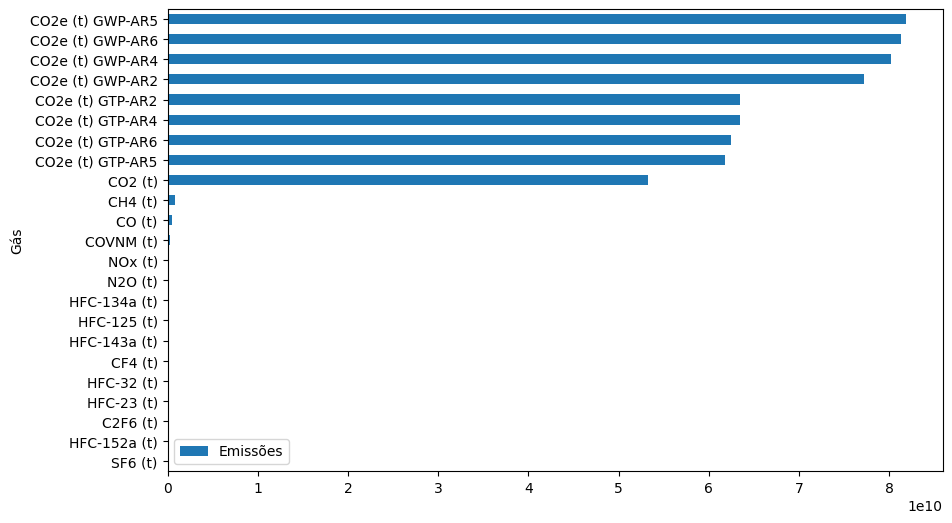

In [27]:
emissões_gases.plot(kind = 'barh', figsize = (10,6))

In [28]:
emissões_gases

,Emissões
Gás,
SF6 (t),4.705800e+02
HFC-152a (t),5.706000e+02
C2F6 (t),5.765018e+02
HFC-23 (t),1.197840e+03
HFC-32 (t),2.367750e+03
CF4 (t),7.135481e+03
HFC-143a (t),9.039400e+03
HFC-125 (t),9.795580e+03
HFC-134a (t),1.394731e+05


<P>ATIVIDADES</P>

<P>Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para visualizar o dicionário contendo as chaves de grupos formados e a lista de índices de cada grupo.</P>

In [29]:
emissoes_estados.groupby('Nível 1 - Setor').groups

{'Agropecuária': [1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, ...], 'Energia': [23277, 23278, 23279, 23280, 23281, 23282, 23283, 23284, 23285, 23286, 23287, 23288, 23289, 23290, 23291, 23292, 23293, 23294, 23295, 23296, 23297, 23298, 23299, 23300, 23301, 23302, 23303, 23304, 23305, 23306, 23307, 23308, 23309, 23310, 23311, 23312, 23313, 23314, 23315, 23316, 23317, 23318, 23319, 23320, 23321, 23322, 23323, 23324, 23325, 23326, 23327, 23328, 

<P>Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" e localize os dados do grupo "Agropecuária".</P>

In [30]:
emissoes_estados.groupby('Nível 1 - Setor').get_group('Agropecuária')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Anos,Emissões
1137,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AC,AGR,ALIM_BEBIDAS,1970,0.000000
1138,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AL,AGR,ALIM_BEBIDAS,1970,2050.445805
1139,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AM,AGR,ALIM_BEBIDAS,1970,0.000000
1140,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AP,AGR,ALIM_BEBIDAS,1970,0.000000
1141,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),BA,AGR,ALIM_BEBIDAS,1970,466.934705
...,...,...,...,...,...,...,...,...,...,...,...,...
4855420,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),RS,AGR,ALIM_BEBIDAS,2021,929.545042
4855421,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),SC,AGR,ALIM_BEBIDAS,2021,295.813919
4855422,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),SE,AGR,ALIM_BEBIDAS,2021,32.734589
4855423,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),SP,AGR,ALIM_BEBIDAS,2021,653.155812


<P>Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para identificar a média de emissão de cada setor no ano de 2021.</P>

In [31]:
emissoes_estados.loc[emissoes_estados['Anos'] == 2021].groupby('Nível 1 - Setor')[['Emissões']].mean()

,Emissões
Nível 1 - Setor,
Agropecuária,149793.768835
Energia,72928.637234
Mudança de Uso da Terra e Floresta,690085.511209
Processos Industriais,787101.255789
Resíduos,106106.723386


<P>Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para identificar a soma de emissão de cada setor. Ordene os dados da maior para menor emissão.</P>

In [32]:
emissoes_estados.groupby('Nível 1 - Setor')[['Emissões']].sum().sort_values('Emissões',ascending = False)

,Emissões
Nível 1 - Setor,
Mudança de Uso da Terra e Floresta,3.524898e+11
Energia,1.205314e+11
Agropecuária,1.147284e+11
Processos Industriais,2.849965e+10
Resíduos,1.034465e+10


In [33]:
gases_setor = emissoes_estados.groupby(['Gás','Nível 1 - Setor'])[['Emissões']].sum()

In [34]:
gases_setor

Emissões
Gás      Nível 1 - Setor                                 
C2F6 (t) Processos Industriais               5.765018e+02
CF4 (t)  Processos Industriais               7.135481e+03
CH4 (t)  Agropecuária                        5.928481e+08
         Energia                             3.429034e+07
         Mudança de Uso da Terra e Floresta  8.662166e+07
...                                                   ...
N2O (t)  Resíduos                            2.764127e+05
NOx (t)  Agropecuária                        2.602719e+06
         Energia                             9.361215e+07
         Processos Industriais               3.546360e+06
SF6 (t)  Processos Industriais               4.705800e+02

[72 rows x 1 columns]

In [35]:
gases_setor.loc['CO2 (t)']

,Emissões
Nível 1 - Setor,
Agropecuária,5.411750e+08
Energia,1.261352e+10
Mudança de Uso da Terra e Floresta,3.733930e+10
Processos Industriais,2.729603e+09
Resíduos,2.276264e+07


In [36]:
gases_setor.xs('CO2 (t)',level = 0).sort_values('Emissões')

,Emissões
Nível 1 - Setor,
Resíduos,2.276264e+07
Agropecuária,5.411750e+08
Processos Industriais,2.729603e+09
Energia,1.261352e+10
Mudança de Uso da Terra e Floresta,3.733930e+10


In [37]:
gases_setor.xs(('CO2 (t)','Mudança de Uso da Terra e Floresta'),level = [0,1])

,,Emissões
Gás,Nível 1 - Setor,
CO2 (t),Mudança de Uso da Terra e Floresta,3.733930e+10


In [38]:
gases_setor.xs('CO2 (t)',level = 0).max()

Emissões    3.733930e+10
dtype: float64

In [39]:
gases_setor.xs('CO2 (t)',level = 0).idxmax()

Emissões    Mudança de Uso da Terra e Floresta
dtype: str

In [40]:
gases_setor.groupby(level=0).idxmax()

,Emissões
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


In [41]:
gases_setor.groupby(level=0).max()

,Emissões
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),5.928481e+08
CO (t),3.959769e+08
CO2 (t),3.733930e+10
CO2e (t) GTP-AR2,3.850044e+10
CO2e (t) GTP-AR4,3.850044e+10
CO2e (t) GTP-AR5,3.831675e+10
CO2e (t) GTP-AR6,3.843359e+10


In [94]:
gases_setor

Emissões
Gás      Nível 1 - Setor                                 
C2F6 (t) Processos Industriais               5.765018e+02
CF4 (t)  Processos Industriais               7.135481e+03
CH4 (t)  Agropecuária                        5.928481e+08
         Energia                             3.429034e+07
         Mudança de Uso da Terra e Floresta  8.662166e+07
...                                                   ...
N2O (t)  Resíduos                            2.764127e+05
NOx (t)  Agropecuária                        2.602719e+06
         Energia                             9.361215e+07
         Processos Industriais               3.546360e+06
SF6 (t)  Processos Industriais               4.705800e+02

[72 rows x 1 columns]

In [42]:
max_setor = gases_setor.groupby(level=0).idxmax()
gas_max = gases_setor.groupby(level=0).max().values
max_setor.insert(1,'Quantidade de emissão',gas_max)
max_setor

,Emissões,Quantidade de emissão
Gás,,
C2F6 (t),"(C2F6 (t), Processos Industriais)",5.765018e+02
CF4 (t),"(CF4 (t), Processos Industriais)",7.135481e+03
CH4 (t),"(CH4 (t), Agropecuária)",5.928481e+08
CO (t),"(CO (t), Energia)",3.959769e+08
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)",3.733930e+10
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F...",3.831675e+10
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F...",3.843359e+10


In [43]:
gases_setor.swaplevel(0,1).groupby(level=0).idxmax()

,Emissões
Nível 1 - Setor,
Agropecuária,"(Agropecuária, CO2e (t) GWP-AR5)"
Energia,"(Energia, CO2e (t) GWP-AR6)"
Mudança de Uso da Terra e Floresta,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
Processos Industriais,"(Processos Industriais, CO2e (t) GWP-AR6)"
Resíduos,"(Resíduos , CO2e (t) GWP-AR5)"


<P>Emissões ao longo dos anos</P>

In [44]:
emissoes_ano = emissoes_estados.groupby('Anos')[['Emissões']].mean()

In [45]:
emissoes_ano.idxmax()

Emissões    2003
dtype: int64

In [46]:
emissoes_ano = emissoes_estados.groupby(['Anos','Gás'])[['Emissões']].mean()

In [47]:
emissoes_ano

Emissões
Anos Gás                     
1970 C2F6 (t)        0.232610
     CF4 (t)         3.557421
     CH4 (t)      1471.024024
     CO (t)       2155.556658
     CO2 (t)     19244.913199
...                       ...
2021 HFC-23 (t)      0.000000
     HFC-32 (t)    261.100000
     N2O (t)       119.295311
     NOx (t)       679.395431
     SF6 (t)         5.240000

[1196 rows x 1 columns]

In [48]:
emissoes_ano = emissoes_ano.reset_index()

In [49]:
emissoes_ano

,Anos,Gás,Emissões
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


In [50]:
emissoes_ano = emissoes_ano.pivot_table(index = 'Anos', columns='Gás',values = 'Emissões')

In [51]:
emissoes_ano

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Anos,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1471.024024,2155.556658,19244.913199,20821.379814,20821.379814,19162.726020,19775.283385,35396.183865,...,742.074863,0.000000,0.000000,0.000000,0.0,0.00,0.00,31.632709,154.072797,0.000
1971,0.334611,5.117360,1525.506914,2259.625805,21598.587743,22466.288595,22466.288595,20748.481445,21386.175802,37570.982886,...,730.119047,0.000000,0.000000,0.000000,0.0,0.00,0.00,32.609237,170.550178,0.000
1972,0.404684,6.189025,1584.719568,2418.944795,23664.445521,24100.305265,24100.305265,22303.224240,22966.797327,39800.768350,...,774.278817,0.000000,0.000000,0.000000,0.0,0.00,0.00,34.311864,188.856161,0.000
1973,0.463147,7.083136,1642.612439,2596.053853,27726.668829,26683.827206,26683.827206,24827.077028,25516.409611,42947.755490,...,796.866394,0.000000,0.000000,0.000000,0.0,0.00,0.00,35.278689,217.320480,0.000
1974,0.471026,7.203619,1704.614365,2681.450599,30155.918952,28539.318732,28539.318732,26600.481407,27321.124852,45431.240064,...,1024.694923,0.000000,0.000000,0.000000,0.0,0.00,0.00,37.098183,247.521415,0.000
1975,0.502952,7.691893,1854.360821,2730.894830,32292.965771,30593.767465,30593.767465,28507.669059,29285.642221,48944.729581,...,1065.682750,0.000000,0.000000,0.000000,0.0,0.00,0.00,39.451008,262.716346,0.000
1976,0.577172,8.826970,1932.641716,2702.494362,35640.344723,33066.878007,33066.878007,30879.481709,31693.226162,52203.028009,...,1091.778909,0.000000,0.000000,0.000000,0.0,0.00,0.00,41.583225,287.013048,0.000
1977,0.692855,10.596169,1931.897645,2675.992077,37313.909077,34182.312333,34182.312333,31967.243034,32784.131397,53333.605735,...,1147.712448,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.571086,292.405821,0.000
1978,0.749660,11.464915,1921.281930,2755.891877,40669.820049,35969.633601,35969.633601,33762.778999,34580.720998,55015.291182,...,1289.853564,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.426649,322.982906,0.000


array([<Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>], dtype=object)

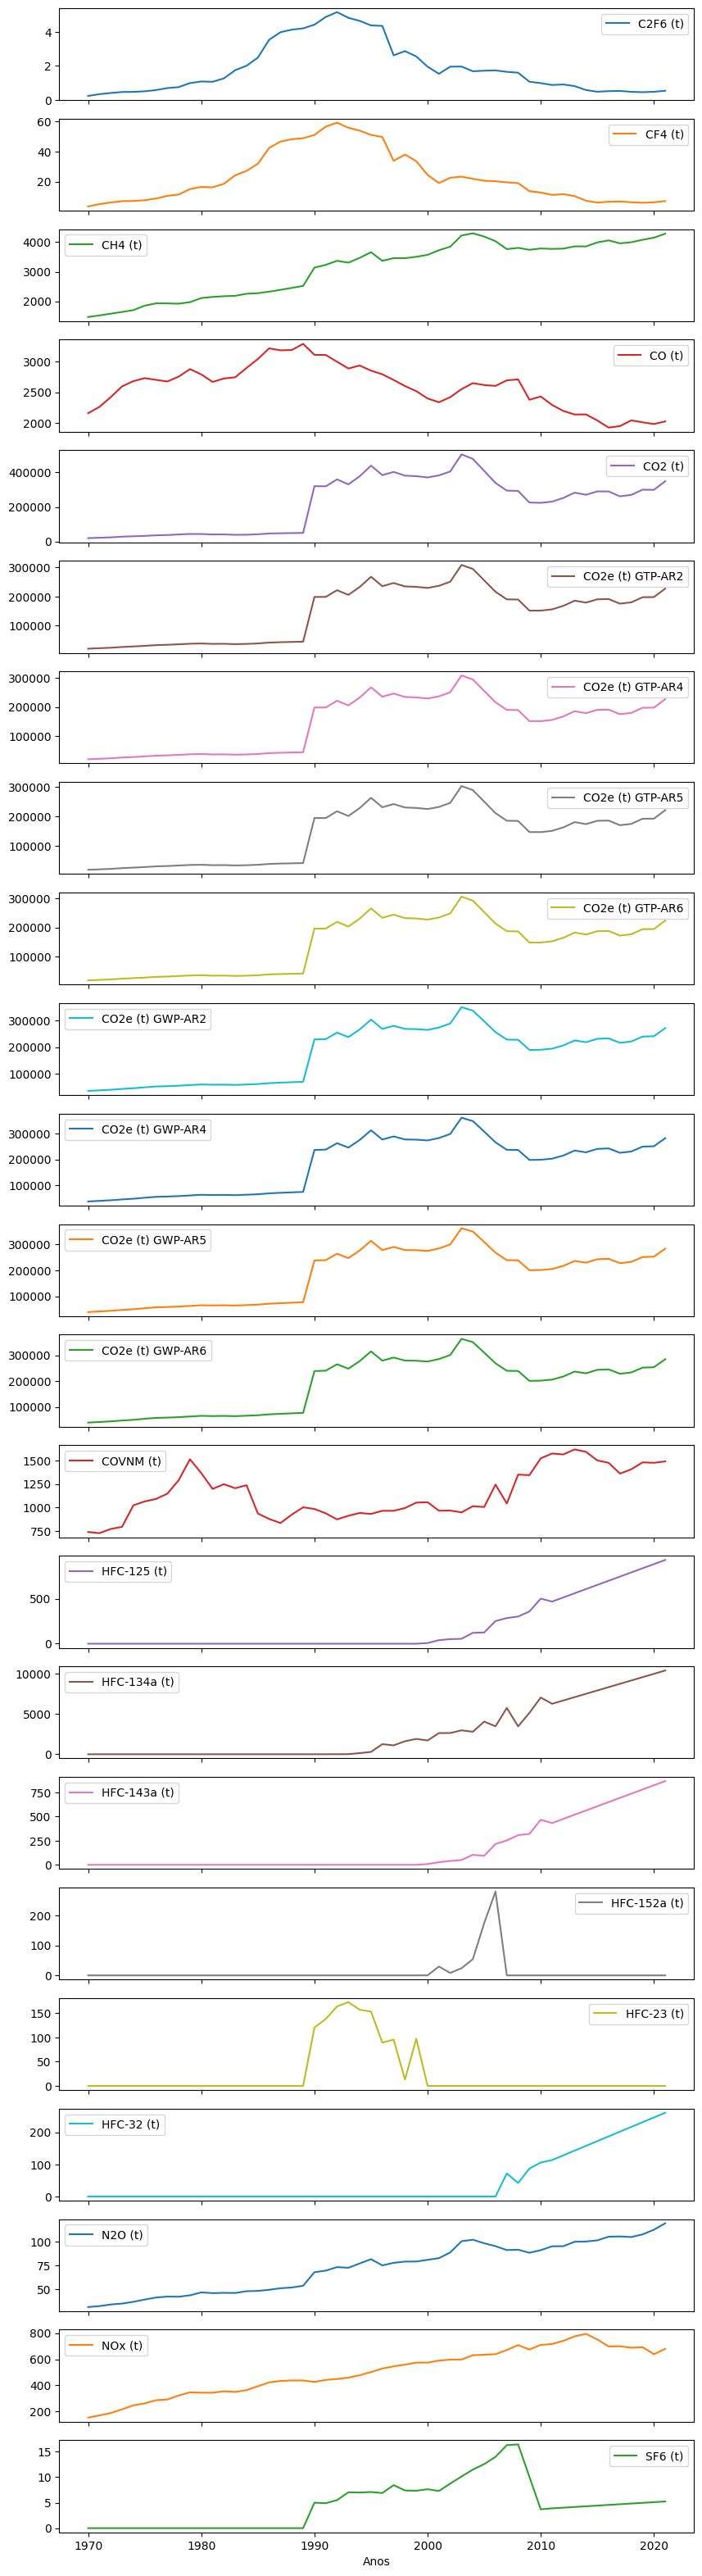

In [52]:
emissoes_ano.plot(subplots = True, figsize = (10,40))

<P>Atividades</P>

<P>Desafio: emissão por setor econômico


Uma das tarefas passadas pela equipe de supervisão do órgão ambiental era de encontrar a emissão média de cada gás por ano. Conseguimos realizar essa tarefa usando o método groupby() e pivot_table() para gerar uma tabela contendo a emissão ao longo dos anos para cada um dos gases.

A equipe de supervisão deseja saber agora a média de emissão para cada um dos setores econômicos da coluna "Nível 1 - Setor" ao longo dos anos. Como desafio, crie uma tabela de pivô e uma visualização gráfica contendo essas informações, utilizando apenas o método pivot_table para a construção da tabela, sem utilizar o método groupby.</P>

In [95]:
emissoes_setores = emissoes_estados.pivot_table(index = 'Anos', columns = 'Nível 1 - Setor', values= 'Emissões')
emissoes_setores

Nível 1 - Setor,Agropecuária,Energia,Mudança de Uso da Terra e Floresta,Processos Industriais,Resíduos
Anos,,,,,
1970,49292.425313,15939.703116,0.000000e+00,106549.168676,11684.883558
1971,51199.559433,17698.989894,0.000000e+00,111532.507753,12676.706849
1972,53508.935498,19092.876761,0.000000e+00,125701.525455,13709.697850
1973,55494.006224,22062.085929,0.000000e+00,137657.110402,14715.248028
1974,57896.513900,23810.659474,0.000000e+00,149941.779638,15710.616150
1975,63303.098508,25036.433686,0.000000e+00,168471.860169,16667.446706
1976,66347.533521,27214.281091,0.000000e+00,193826.482068,17539.505222
1977,66977.413505,27645.258640,0.000000e+00,231505.609283,18462.455148
1978,66640.432009,29734.461056,0.000000e+00,255736.210711,19327.840165


array([<Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>, <Axes: xlabel='Anos'>,
       <Axes: xlabel='Anos'>], dtype=object)

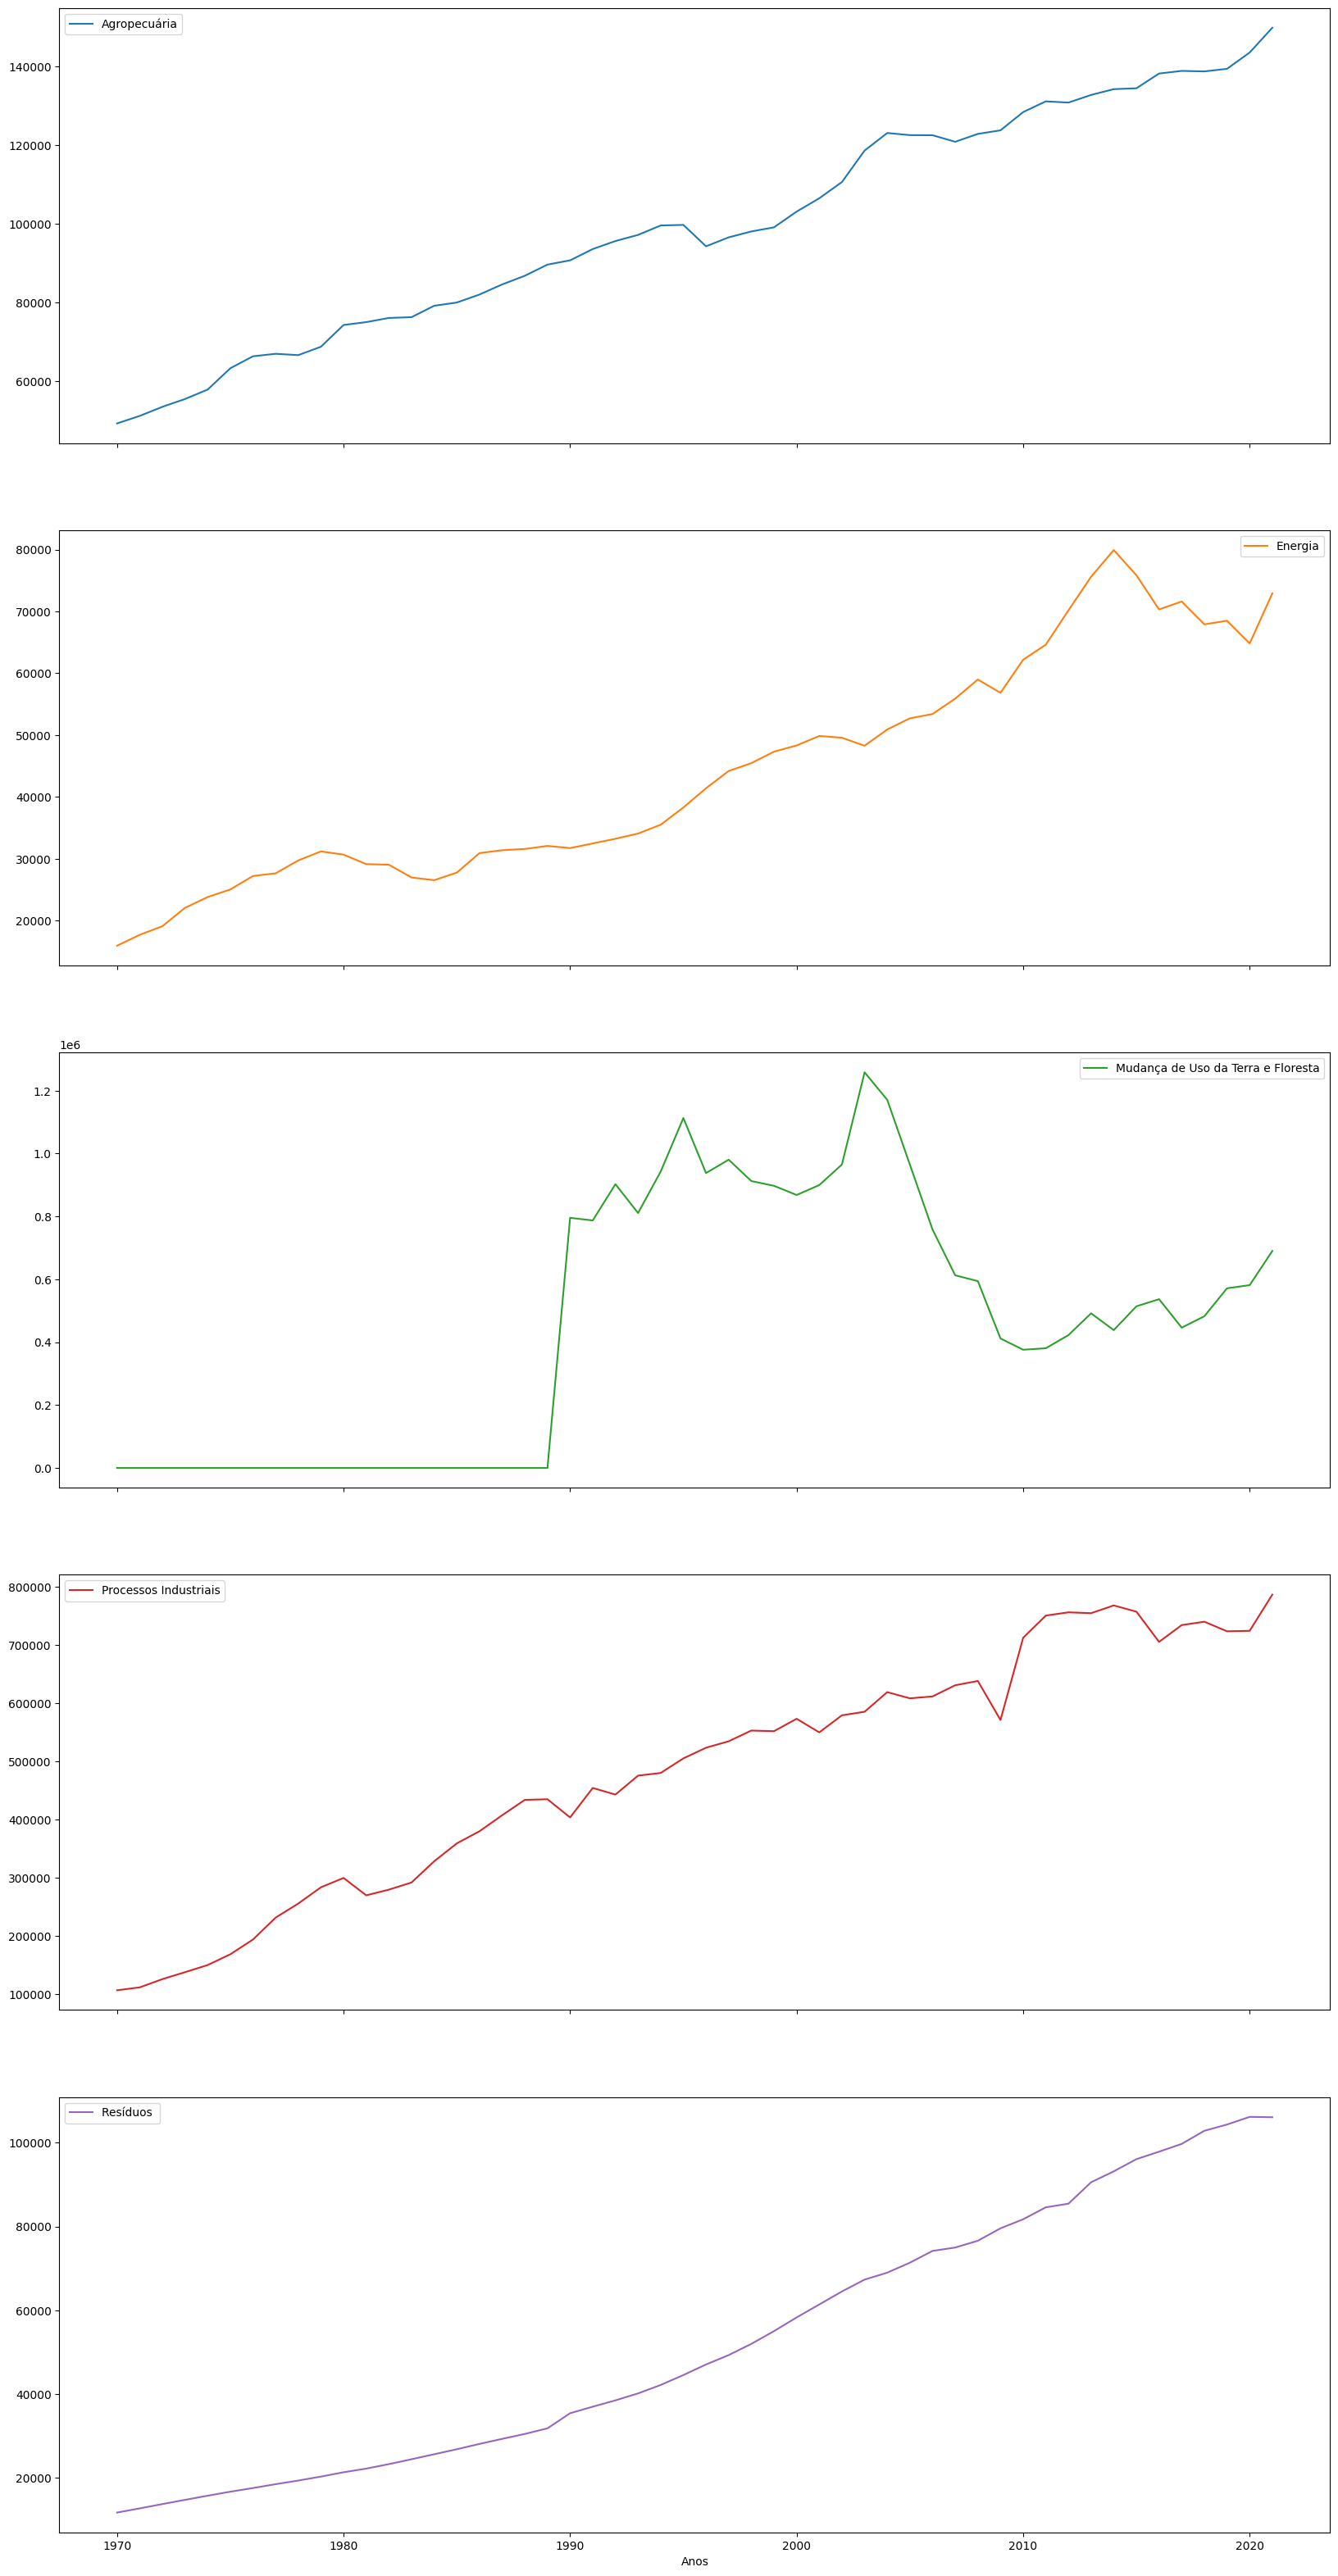

In [54]:
emissoes_setores.plot(subplots = True, figsize = (20,40))

<P>Faça um agrupamento de dados com as colunas "Estado" e "Nível 1 - Setor", obtendo a soma de emissão e armazenando o resultado em uma tabela.</P>

In [55]:
emissoes_estados_setor = emissoes_estados.groupby(['Estado','Nível 1 - Setor'])[['Emissões']].sum()
emissoes_estados_setor

Emissões
Estado Nível 1 - Setor                                 
AC     Agropecuária                        7.270206e+08
       Energia                             2.071751e+08
       Mudança de Uso da Terra e Floresta  7.847879e+09
       Resíduos                            2.928323e+07
AL     Agropecuária                        7.628303e+08
...                                                 ...
TO     Agropecuária                        2.762475e+09
       Energia                             5.130379e+08
       Mudança de Uso da Terra e Floresta  9.435591e+09
       Processos Industriais               2.613905e+07
       Resíduos                            6.177003e+07

[132 rows x 1 columns]

<P>Utilizando a tabela construída na atividade 1, selecione os dados referentes à "Energia" do índice "Nível 1 - Setor".</P>

In [56]:
emissoes_estados_setor.xs('Energia', level = 1)

,Emissões
Estado,
AC,2.071751e+08
AL,5.958697e+08
AM,1.916462e+09
AP,2.638059e+08
BA,4.801368e+09
CE,1.879584e+09
DF,9.487860e+08
ES,2.201326e+09
GO,2.761709e+09


<P>Utilizando a tabela construída na atividade 1, encontre a atividade econômica com valor máximo de emissão do Estado de Minas Gerais</P>

In [57]:
emissoes_estados_setor.xs('MG',level = 0).idxmax()

Emissões    Agropecuária
dtype: str

In [58]:
emissoes_estados_setor.groupby(level = 0).idxmax()

,Emissões
Estado,
AC,"(AC, Mudança de Uso da Terra e Floresta)"
AL,"(AL, Agropecuária)"
AM,"(AM, Mudança de Uso da Terra e Floresta)"
AP,"(AP, Mudança de Uso da Terra e Floresta)"
BA,"(BA, Mudança de Uso da Terra e Floresta)"
CE,"(CE, Energia)"
DF,"(DF, Energia)"
ES,"(ES, Processos Industriais)"
GO,"(GO, Agropecuária)"


In [59]:
emissoes_estados_setor.groupby(level = 1).idxmax()

,Emissões
Nível 1 - Setor,
Agropecuária,"(MG, Agropecuária)"
Energia,"(SP, Energia)"
Mudança de Uso da Terra e Floresta,"(PA, Mudança de Uso da Terra e Floresta)"
Processos Industriais,"(MG, Processos Industriais)"
Resíduos,"(SP, Resíduos )"


In [60]:
emissoes_estados

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Anos,Emissões
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


In [63]:
emissoes_estados.groupby('Estado')[['Emissões']].sum()


,Emissões
Estado,
AC,8.811358e+09
AL,2.018218e+09
AM,1.823281e+10
AP,1.704683e+09
BA,2.401011e+10
CE,6.026543e+09
DF,1.550956e+09
ES,7.315333e+09
GO,2.229122e+10


In [67]:
grupo_estados = emissoes_estados.groupby('Estado')
grupo_estados.groups

{'AC': [1137, 1164, 1191, 1218, 1245, 1272, 1299, 1326, 1353, 1380, 1407, 1434, 1461, 1488, 1515, 1542, 1569, 1596, 1623, 1650, 1677, 1704, 1731, 1758, 1785, 1812, 1839, 1866, 1893, 1920, 1947, 1974, 2001, 2028, 2055, 2082, 2109, 2136, 2163, 2190, 2217, 2244, 2271, 2298, 2325, 2352, 2379, 2406, 2433, 2460, 2487, 2514, 2541, 2568, 2595, 2622, 2649, 2676, 2703, 2730, 2757, 2784, 2811, 2838, 2865, 2892, 2919, 2946, 2973, 3000, 3027, 3054, 3081, 3108, 3135, 3162, 3189, 3216, 3243, 3270, 3297, 3324, 3351, 3378, 3405, 3432, 3459, 3486, 3513, 3540, 3567, 3594, 3621, 3648, 3675, 3702, 3729, 3756, 3783, 3810, ...], 'AL': [99, 124, 149, 575, 600, 779, 804, 983, 1008, 1138, 1165, 1192, 1219, 1246, 1273, 1300, 1327, 1354, 1381, 1408, 1435, 1462, 1489, 1516, 1543, 1570, 1597, 1624, 1651, 1678, 1705, 1732, 1759, 1786, 1813, 1840, 1867, 1894, 1921, 1948, 1975, 2002, 2029, 2056, 2083, 2110, 2137, 2164, 2191, 2218, 2245, 2272, 2299, 2326, 2353, 2380, 2407, 2434, 2461, 2488, 2515, 2542, 2569, 2596, 2623

In [68]:
grupo_estados.get_group('GO')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Anos,Emissões
104,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2 (t),GO,CIM,NaN,1970,0.0
129,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2e (t) GWP-AR2,GO,CIM,NaN,1970,0.0
154,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2e (t) GTP-AR2,GO,CIM,NaN,1970,0.0
580,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2e (t) GWP-AR4,GO,CIM,NaN,1970,0.0
605,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2e (t) GTP-AR4,GO,CIM,NaN,1970,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926794,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Mata Atlântica,NaN,Desmatamento,NaN,CO2e (t) GWP-AR2,GO,AGROPEC,NaN,2021,9141.0
4926809,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Mata Atlântica,NaN,Desmatamento,NaN,CO2e (t) GWP-AR4,GO,AGROPEC,NaN,2021,10182.0
4926824,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Mata Atlântica,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,GO,AGROPEC,NaN,2021,10726.0
4926839,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Mata Atlântica,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,GO,AGROPEC,NaN,2021,10777.0


In [71]:
emissao_n2_estado = emissoes_estados.groupby(['Nível 2','Estado'])
emissao_n2_estado.groups

{('Alterações de Uso da Terra',
  'AC'): Index([  79760,   79769,   79778,   79787,   79796,   79805,   79814,   79823,
          79832,   79895,
        ...
        4914329, 4914338, 4914347, 4914356, 4914365, 4914374, 4914383, 4914392,
        4914401, 4914410],
       dtype='int64', length=10764),
 ('Alterações de Uso da Terra',
  'AL'): Index([  82271,   82280,   82289,   82298,   82307,   82316,   82325,   82334,
          82343,   82388,
        ...
        4925393, 4925408, 4925422, 4925436, 4925450, 4925464, 4925478, 4925492,
        4925506, 4925520],
       dtype='int64', length=21528),
 ('Alterações de Uso da Terra',
  'AM'): Index([  79762,   79771,   79780,   79789,   79798,   79807,   79816,   79825,
          79834,   79897,
        ...
        4914331, 4914340, 4914349, 4914358, 4914367, 4914376, 4914385, 4914394,
        4914403, 4914412],
       dtype='int64', length=11232),
 ('Alterações de Uso da Terra',
  'AP'): Index([  79761,   79770,   79779,   79788,   79797,  

In [74]:
emissao_n2_estado.get_group(('Solos Manejados',
  'GO'))

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Anos,Emissões
7733,Agropecuária,Solos Manejados,Diretas,Aplicação de resíduos orgânicos,Animal,Aves,CO2e (t) GTP-AR2,GO,PEC,CAR,1970,3485.443500
7760,Agropecuária,Solos Manejados,Diretas,Aplicação de resíduos orgânicos,Animal,Aves,CO2e (t) GTP-AR4,GO,PEC,CAR,1970,3485.443500
7787,Agropecuária,Solos Manejados,Diretas,Aplicação de resíduos orgânicos,Animal,Aves,CO2e (t) GTP-AR5,GO,PEC,CAR,1970,3020.717700
7814,Agropecuária,Solos Manejados,Diretas,Aplicação de resíduos orgânicos,Animal,Aves,CO2e (t) GTP-AR6,GO,PEC,CAR,1970,3007.808650
7841,Agropecuária,Solos Manejados,Diretas,Aplicação de resíduos orgânicos,Animal,Aves,CO2e (t) GWP-AR2,GO,PEC,CAR,1970,4001.805500
...,...,...,...,...,...,...,...,...,...,...,...,...
4855298,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,CO2e (t) GWP-AR2,GO,AGR,ALIM_BEBIDAS,2021,69885.950196
4855325,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,CO2e (t) GWP-AR4,GO,AGR,ALIM_BEBIDAS,2021,67180.687607
4855352,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,CO2e (t) GWP-AR5,GO,AGR,ALIM_BEBIDAS,2021,59741.215490
4855379,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,CO2e (t) GWP-AR6,GO,AGR,ALIM_BEBIDAS,2021,61544.723882


In [78]:
n2_emissao = emissoes_estados.groupby(['Nível 2','Estado'])[['Emissões']].sum()
n2_emissao

Emissões
Nível 2                    Estado              
Alterações de Uso da Terra AC      7.469682e+09
                           AL      4.434855e+08
                           AM      1.476144e+10
                           AP      1.221297e+09
                           BA      1.073251e+10
...                                         ...
Solos Manejados            RS      4.429026e+09
                           SC      1.223222e+09
                           SE      2.287475e+08
                           SP      4.533185e+09
                           TO      9.022270e+08

[351 rows x 1 columns]

In [91]:
n2_emissao.xs(key=('Produtos Minerais','GO'),level=(0,1))

,,Emissões
Nível 2,Estado,
Produtos Minerais,GO,1.716006e+08


In [81]:
n2_emissao.xs('Solos Manejados',level=0)

,Emissões
Estado,
AC,2.014709e+08
AL,3.109738e+08
AM,1.861659e+08
AP,4.479233e+07
BA,2.488198e+09
CE,5.788697e+08
DF,4.823230e+07
ES,5.338270e+08
GO,4.039655e+09


In [93]:
n2_emissao.xs('Solos Manejados',level=0).idxmax()

Emissões    MG
dtype: str

In [96]:
censo = pd.read_excel('POP2022_Municipios.xls',header = 1,skipfooter = 34)
censo

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
0,RO,11,15,Alta Floresta D'Oeste,21558
1,RO,11,23,Ariquemes,100896
2,RO,11,31,Cabixi,5107
3,RO,11,49,Cacoal,92202
4,RO,11,56,Cerejeiras,15237
...,...,...,...,...,...
5565,GO,52,22005,Vianópolis,14046
5566,GO,52,22054,Vicentinópolis,8776
5567,GO,52,22203,Vila Boa,3686
5568,GO,52,22302,Vila Propício,5646


In [97]:
censo.info()

<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   UF                 5570 non-null   str   
 1   COD. UF            5570 non-null   int64 
 2   COD. MUNIC         5570 non-null   int64 
 3   NOME DO MUNICÍPIO  5570 non-null   str   
 4   POPULAÇÃO          5570 non-null   object
dtypes: int64(2), object(1), str(2)
memory usage: 217.7+ KB


In [98]:
censo[censo['POPULAÇÃO'].str.contains('\(', na = False)]

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
C:\Users\marco\AppData\Local\Temp\ipykernel_20416\2682155060.py:1: SyntaxWarning: invalid escape sequence '\('
  censo[censo['POPULAÇÃO'].str.contains('\(', na = False)]


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
16,RO,11,205,Porto Velho,461.748(1)
74,AM,13,29,Alvarães,15.916(2)
81,AM,13,409,Barcelos,18.399(3)
83,AM,13,607,Benjamin Constant,37.436(4)
87,AM,13,805,Borba,33.209(5)
88,AM,13,839,Caapiranga,13.851(6)
97,AM,13,1605,Fonte Boa,27.692(7)
98,AM,13,1654,Guajará,13.809(8)
99,AM,13,1704,Humaitá,59.504(9)
103,AM,13,1951,Itamarati,10.783(10)


In [99]:
censo['POPULAÇÃO'] = censo['POPULAÇÃO'].replace('\(\d{1,2}\)','',regex=True)
censo['POPULAÇÃO'] = censo['POPULAÇÃO'].replace('\.','',regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\marco\AppData\Local\Temp\ipykernel_20416\2750182299.py:1: SyntaxWarning: invalid escape sequence '\('
  censo['POPULAÇÃO'] = censo['POPULAÇÃO'].replace('\(\d{1,2}\)','',regex=True)
C:\Users\marco\AppData\Local\Temp\ipykernel_20416\2750182299.py:2: SyntaxWarning: invalid escape sequence '\.'
  censo['POPULAÇÃO'] = censo['POPULAÇÃO'].replace('\.','',regex=True)


In [100]:
censo.head(25)

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
0,RO,11,15,Alta Floresta D'Oeste,21558
1,RO,11,23,Ariquemes,100896
2,RO,11,31,Cabixi,5107
3,RO,11,49,Cacoal,92202
4,RO,11,56,Cerejeiras,15237
5,RO,11,64,Colorado do Oeste,15747
6,RO,11,72,Corumbiara,7503
7,RO,11,80,Costa Marques,12633
8,RO,11,98,Espigão D'Oeste,29722
9,RO,11,106,Guajará-Mirim,39396


In [101]:
censo['POPULAÇÃO'] = censo['POPULAÇÃO'].astype('int64')

In [102]:
censo.info()

<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   UF                 5570 non-null   str  
 1   COD. UF            5570 non-null   int64
 2   COD. MUNIC         5570 non-null   int64
 3   NOME DO MUNICÍPIO  5570 non-null   str  
 4   POPULAÇÃO          5570 non-null   int64
dtypes: int64(3), str(2)
memory usage: 217.7 KB


In [103]:
censo_estado = censo.groupby('UF')[['POPULAÇÃO']].sum()

In [114]:
emissao_estado = emissoes_estados.loc[emissoes_estados['Anos']==2021].groupby('Estado')[['Emissões']].sum().reset_index()

In [115]:
emissao_estado

,Estado,Emissões
0,AC,3.505471e+08
1,AL,6.261279e+07
2,AM,1.189649e+09
3,AP,3.568410e+07
4,BA,5.932251e+08
5,CE,2.034731e+08
6,DF,5.668738e+07
7,ES,2.697547e+08
8,GO,6.008081e+08
9,MA,9.476324e+08


In [118]:
agrupado = pd.merge(emissao_estado,censo_estado,left_on = 'Estado',right_on = 'UF')
agrupado

,Estado,Emissões,POPULAÇÃO
0,AC,3.505471e+08,829780
1,AL,6.261279e+07,3125254
2,AM,1.189649e+09,3952262
3,AP,3.568410e+07,774268
4,BA,5.932251e+08,14659023
5,CE,2.034731e+08,8936431
6,DF,5.668738e+07,2923369
7,ES,2.697547e+08,3975100
8,GO,6.008081e+08,6950976
9,MA,9.476324e+08,6800605


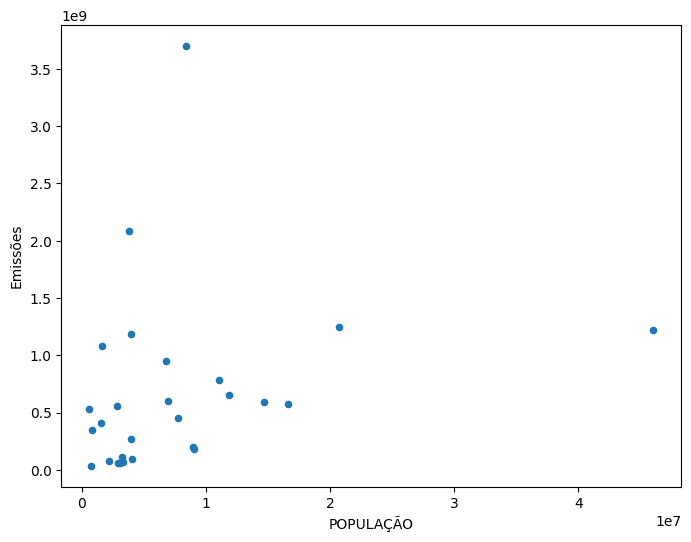

In [121]:
agrupado.plot(x = 'POPULAÇÃO',y='Emissões', kind= 'scatter',figsize=(8,6));

<p>Emissão per capita</p>

In [139]:
import plotly.express as px

In [146]:
px.scatter(data_frame = agrupado,x = 'POPULAÇÃO',y='Emissões', text='Estado',opacity = 0)

In [141]:
agrupado.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Estado              27 non-null     str    
 1   Emissões            27 non-null     float64
 2   POPULAÇÃO           27 non-null     int64  
 3   Emissão per capita  27 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 996.0 bytes


In [142]:
agrupado['Emissão per capita'] = (agrupado['Emissões']/agrupado['POPULAÇÃO'])
agrupado

,Estado,Emissões,POPULAÇÃO,Emissão per capita
0,AC,3.505471e+08,829780,422.457928
1,AL,6.261279e+07,3125254,20.034465
2,AM,1.189649e+09,3952262,301.004463
3,AP,3.568410e+07,774268,46.087533
4,BA,5.932251e+08,14659023,40.468254
5,CE,2.034731e+08,8936431,22.768949
6,DF,5.668738e+07,2923369,19.391113
7,ES,2.697547e+08,3975100,67.861099
8,GO,6.008081e+08,6950976,86.435075
9,MA,9.476324e+08,6800605,139.345312


In [147]:
px.bar(data_frame = agrupado,x = 'Estado',y='Emissão per capita')